**Navigation:**  
[← Rt Decomposition](06_rt_wells_riley_decomposition.ipynb) | [Timed Interventions →](08_timed_interventions.ipynb)

# Interventions: Policy Language to Model Controls

This notebook is an illustrative bridge between policy concepts and model parameters.

Map/Territory note:
- Territory: ventilation, masking, tracing, isolation, and behavior changes in real settings
- Map: within-group and bridge transmission scalars in a contact matrix

The purpose is pedagogical: make assumptions explicit and test consequences.

## Policy-to-Model Translation (Working Draft)

| Policy framing | Model control |
| --- | --- |
| Improve ventilation/masking in cluster settings | scale cluster diagonal entry (within-group) |
| Contact tracing + isolation of bridge cases | scale specific bridge entries between groups |
| Broad social distancing | scale many off-diagonal entries and possibly all diagonals |
| Targeted vaccination in one group | (future) change susceptible stock or effective transmission in that group |

In [ ]:
from pathlib import Path
import sys

project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))

if "epi" in globals():
    epi = epi.reload_package_modules("epi_structure")
else:
    import epi_structure as epi

from epi_structure import (
    DiseaseParameters,
    PopulationParameters,
    SimulationParameters,
    StructuredEpidemicModel,
    Scenario,
    effective_matrix as effective_matrix_helper,
    get_scenario,
    intervention_targets as intervention_targets_helper,
    list_scenarios,
    plot_matrix_transformation,
    plot_population_infected_comparison,
    run_scenario,
    summarize_two_population_runs,
)

import pandas as pd
import matplotlib.pyplot as plt

epi_structure already loaded; restart kernel to pick up package changes.


In [17]:
# Load the baseline scenario configuration
baseline = get_scenario("baseline")
names = baseline.population_names
contact_matrix = baseline.contact_matrix
populations = baseline.populations
simulation = baseline.simulation

display(pd.DataFrame(contact_matrix, index=names, columns=names))

,general,cluster
general,0.00004,0.00018
cluster,0.00001,0.00050


In [3]:
# Builder-style setup with transition lookup syntax and relative adjustments.
g_from_cluster = baseline["general", "cluster"]
c_from_general = baseline["cluster", "general"]
c_within = baseline["cluster", "cluster"]

builder_demo = (
    Scenario.builder(base=baseline, name="builder_relative_transition_demo")
    .description("Example: relative transition edits via Scenario indexing")
    .transition("general", "cluster", g_from_cluster * 0.60)  # reduce spillover 40%
    .transition("cluster", "general", c_from_general * 1.80)  # increase reverse coupling
    .transition("cluster", "cluster", c_within * 1.30)        # increase within-cluster mixing
    .build()
)

# Manual scenario tweaking via assignment syntax.
builder_demo["general", "general"] = baseline["general", "general"] * 0.95

builder_df = pd.DataFrame(
    builder_demo.contact_matrix,
    index=builder_demo.population_names,
    columns=builder_demo.population_names,
).round(6)

baseline_df = pd.DataFrame(contact_matrix, index=names, columns=names).round(6)
delta_df = (builder_df - baseline_df).round(6)

display(builder_df)
display(delta_df)

,general,cluster
general,0.000038,0.000108
cluster,0.000018,0.000650


,general,cluster
general,-0.000002,-0.000072
cluster,0.000008,0.000150


In [4]:
def effective_matrix(scenario_name: str, time: float) -> list[list[float]]:
    """Compute effective contact matrix at a given time under a scenario."""
    return effective_matrix_helper(
        scenario_name=scenario_name,
        base_contact_matrix=contact_matrix,
        population_names=names,
        time=time,
    )


def intervention_targets(scenario_name: str):
    """Extract targeted groups and bridge links from a scenario's intervention plan."""
    return intervention_targets_helper(
        scenario_name=scenario_name,
        population_names=names,
    )

## Visual Map: Groups and Bridge Links

This view makes the transformation explicit:
- choose a policy (selector)
- identify the targeted groups/links (subset)
- compare base vs effective matrix at a chosen time (transform result)

,general,cluster
general,0.00004,0.00018
cluster,0.00001,0.00050


,general,cluster
general,0.000040,0.000036
cluster,0.000002,0.000200


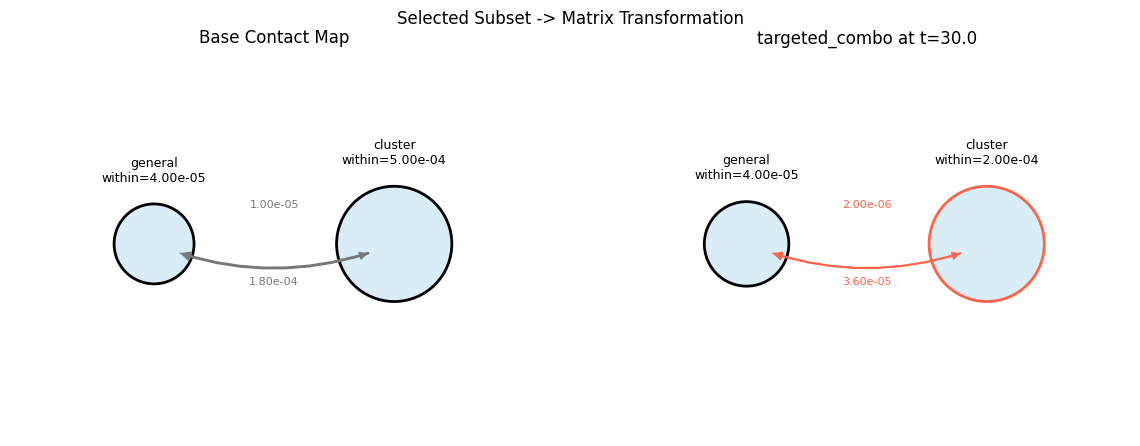

In [5]:
scenario_to_view = "targeted_combo"
time_to_view = 30.0

groups, links = intervention_targets(scenario_to_view)
base_matrix = [row[:] for row in contact_matrix]
effective = effective_matrix(scenario_to_view, time_to_view)

display(pd.DataFrame(base_matrix, index=names, columns=names).round(6))
display(pd.DataFrame(effective, index=names, columns=names).round(6))

plot_matrix_transformation(
    names=names,
    base_matrix=base_matrix,
    effective=effective,
    title=f"{scenario_to_view} at t={time_to_view}",
    highlighted_groups=groups,
    highlighted_links=links,
)
plt.show()

In [6]:
scenario_names = list_scenarios()
runs = {name: run_scenario(name) for name in scenario_names}

len(runs), {k: len(v) for k, v in runs.items()}

(4,
 {'baseline': 61,
  'bridge_tracing': 61,
  'cluster_ventilation': 61,
  'targeted_combo': 61})

In [7]:
summary = summarize_two_population_runs(
    scenario_names=scenario_names,
    runs=runs,
    general_name="general",
    cluster_name="cluster",
    general_size=10_000,
    cluster_size=500,
)
summary.round(3)

,scenario,general_peak_I,general_peak_t,general_end_I,general_peak_pct,cluster_peak_I,cluster_peak_t,cluster_end_I,cluster_peak_pct
0,baseline,1896.851,40.0,524.685,18.969,74.068,43.0,34.848,14.814
1,bridge_tracing,1637.209,41.0,613.132,16.372,41.613,49.0,34.325,8.323
2,cluster_ventilation,1807.044,40.0,553.086,18.070,47.526,45.0,28.935,9.505
3,targeted_combo,1616.085,41.0,613.573,16.161,14.496,22.0,11.251,2.899


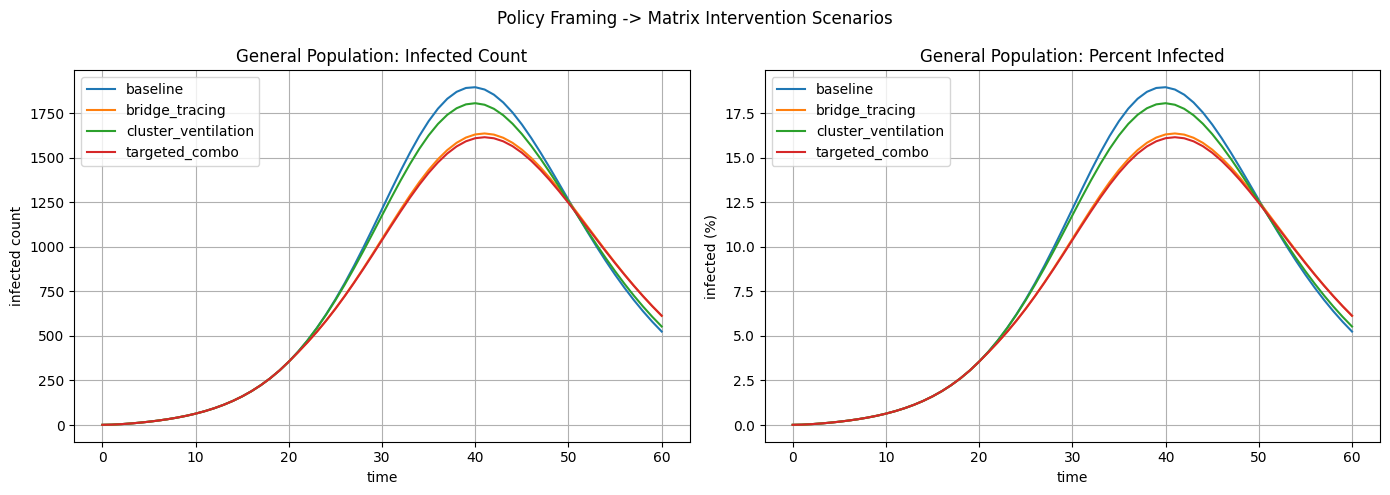

In [8]:
plot_population_infected_comparison(
    runs=runs,
    population_name="general",
    population_size=10_000,
    suptitle="Policy Framing -> Matrix Intervention Scenarios",
)
plt.show()

In [9]:
assert all(len(traj) > 0 for traj in runs.values())
assert set(summary["scenario"]) == set(scenario_names)
assert summary["general_peak_I"].notna().all()
print("Intervention scenario checks passed.")

Intervention scenario checks passed.
